# Multivariate Sensor Change-Point Detection

## Goal

This notebook applies unsupervised change-point detection to a multivariate industrial sensor signal.

The simulated system contains several operating regimes. Each regime may differ through:

- sensor mean levels
- sensor variance
- relationships between sensors
- combinations of several distribution changes

The algorithms receive only the recorded sensor values.

They are not given:

- regime labels
- true change locations
- fault labels
- a target class for each time step

## Main question

Can an unsupervised algorithm detect when the underlying behaviour of a multivariate system changes?

## Algorithms

### PELT

PELT searches for a segmentation that balances:

- within-segment consistency
- the number of detected changes

A penalty controls how expensive it is to add another change point.

### Binary Segmentation

Binary Segmentation repeatedly finds and divides at the strongest remaining change.

### Window-based detection

The Window method compares neighbouring windows and searches for locations where their statistical behaviour differs.


In [2]:
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ruptures as rpt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

NUMBER_OF_OBSERVATIONS = 1_800

SENSOR_COLUMNS = [
    "temperature",
    "pressure",
    "vibration",
    "power_draw"
]

TRUE_CHANGE_POINTS = [
    300,
    620,
    980,
    1_280,
    1_530
]

TRUE_FINAL_BREAKPOINTS = (
    TRUE_CHANGE_POINTS
    + [NUMBER_OF_OBSERVATIONS]
)

MATCHING_TOLERANCE = 15

MINIMUM_SEGMENT_SIZE = 40
JUMP_SIZE = 2


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)

print(
    "ruptures version:",
    getattr(rpt, "__version__", "unknown")
)

print(
    "Observations:",
    NUMBER_OF_OBSERVATIONS
)

print(
    "True change points:",
    TRUE_CHANGE_POINTS
)

ruptures version: v1.1.10
Observations: 1800
True change points: [300, 620, 980, 1280, 1530]


In [3]:
regime_means = np.array([
    [0.0, 0.0, 0.0, 0.0],
    [2.2, 1.4, 0.0, 0.3],
    [2.2, 1.4, 0.0, 0.3],
    [0.4, 2.8, -1.0, 1.6],
    [0.4, 2.8, -1.0, 1.6],
    [-1.4, 0.5, 1.8, -0.6]
])

regime_standard_deviations = np.array([
    [0.50, 0.55, 0.45, 0.50],
    [0.50, 0.55, 0.45, 0.50],
    [0.50, 0.55, 1.50, 0.50],
    [0.60, 0.60, 1.10, 0.70],
    [0.60, 0.60, 1.10, 0.70],
    [0.75, 0.80, 0.75, 0.70]
])

In [5]:
def generate_sensor_regime(
    number_of_rows,
    mean_values,
    standard_deviations,
    regime_index,
    rng
):
    independent_noise = rng.normal(
        size=(
            number_of_rows,
            len(SENSOR_COLUMNS)
        )
    )

    segment = (
        independent_noise
        * standard_deviations
        + mean_values
    )

    shared_factor = rng.normal(
        size=number_of_rows
    )

    if regime_index == 3:
        segment[:, 0] += (
            0.75 * shared_factor
        )

        segment[:, 1] += (
            0.70 * shared_factor
        )

    if regime_index == 4:
        segment[:, 0] += (
            0.75 * shared_factor
        )

        segment[:, 3] -= (
            0.65 * shared_factor
        )

    return segment

In [7]:
def generate_multiregime_signal(
    random_state=42
):
    rng = np.random.default_rng(
        random_state
    )

    boundaries = (
        [0]
        + TRUE_CHANGE_POINTS
        + [NUMBER_OF_OBSERVATIONS]
    )

    segment_arrays = []
    regime_labels = []

    for regime_index in range(
        len(boundaries) - 1
    ):
        start = boundaries[
            regime_index
        ]

        end = boundaries[
            regime_index + 1
        ]

        segment_length = end - start

        segment = generate_sensor_regime(
            number_of_rows=
                segment_length,
            mean_values=
                regime_means[
                    regime_index
                ],
            standard_deviations=
                regime_standard_deviations[
                    regime_index
                ],
            regime_index=
                regime_index,
            rng=rng
        )

        segment_arrays.append(segment)

        regime_labels.extend(
            [regime_index]
            * segment_length
        )

    signal = np.vstack(
        segment_arrays
    )

    candidate_spike_indices = np.array([
        index
        for index in range(
            30,
            NUMBER_OF_OBSERVATIONS - 30
        )
        if all(
            abs(
                index - change_point
            ) > 30
            for change_point
            in TRUE_CHANGE_POINTS
        )
    ])

    spike_indices = rng.choice(
        candidate_spike_indices,
        size=18,
        replace=False
    )

    signal[
        spike_indices,
        2
    ] += rng.normal(
        loc=0.0,
        scale=4.0,
        size=len(spike_indices)
    )

    signal_df = pd.DataFrame(
        signal,
        columns=SENSOR_COLUMNS
    )

    signal_df["time_index"] = np.arange(
        NUMBER_OF_OBSERVATIONS
    )

    signal_df["true_regime"] = (
        regime_labels
    )

    return signal_df, spike_indices

In [8]:
sensor_df, spike_indices = (
    generate_multiregime_signal(
        RANDOM_STATE
    )
)

print("Signal shape:", sensor_df.shape)
print("Injected isolated spikes:", len(spike_indices))

sensor_df.head()

Signal shape: (1800, 6)
Injected isolated spikes: 18


,temperature,pressure,vibration,power_draw,time_index,true_regime
0,0.152359,-0.571991,0.337703,0.470282,0,0
1,-0.975518,-0.716199,0.057528,-0.158121,1,0
2,-0.008401,-0.469174,0.395729,0.388896,2,0
3,0.033015,0.619983,0.210379,-0.429646,3,0
4,0.184375,-0.527385,0.395303,-0.024963,4,0


In [9]:
true_regime_description_df = pd.DataFrame({
    "regime": [0, 1, 2, 3, 4, 5],
    "start": [
        0,
        300,
        620,
        980,
        1_280,
        1_530
    ],
    "end": [
        300,
        620,
        980,
        1_280,
        1_530,
        1_800
    ],
    "main_change": [
        "Initial stable operation",
        "Temperature and pressure mean increase",
        "Vibration variance increases",
        "Several means change and temperature-pressure correlation appears",
        "Temperature-power relationship changes",
        "Final system-wide operating shift"
    ]
})

true_regime_description_df

,regime,start,end,main_change
0,0,0,300,Initial stable operation
1,1,300,620,Temperature and pressure mean increase
2,2,620,980,Vibration variance increases
3,3,980,1280,Several means change and temperature-pressure ...
4,4,1280,1530,Temperature-power relationship changes
5,5,1530,1800,Final system-wide operating shift


## Simulated system 

The generated signal contained:

- 1,800 observations
- 4 sensor channels
- 6 hidden operating regimes
- 5 true change points
- 18 isolated vibration spikes

The sensor channels were:

- temperature
- pressure
- vibration
- power draw

The true boundaries were located at:

`300, 620, 980, 1280, 1530`

The boundaries represented different kinds of system change:

| Boundary | Main process change |
|---:|---|
| 300 | Temperature and pressure means increased |
| 620 | Vibration variance increased |
| 980 | Several sensor means changed and temperature-pressure correlation appeared |
| 1280 | Dependence changed from temperature-pressure correlation to temperature-power correlation |
| 1530 | Large system-wide shift across all sensors |

This made the task more complex than detecting simple mean changes.

The isolated vibration spikes represented short-lived anomalies rather than permanent regime transitions. A useful change-point detector should avoid treating these individual spikes as new operating regimes.

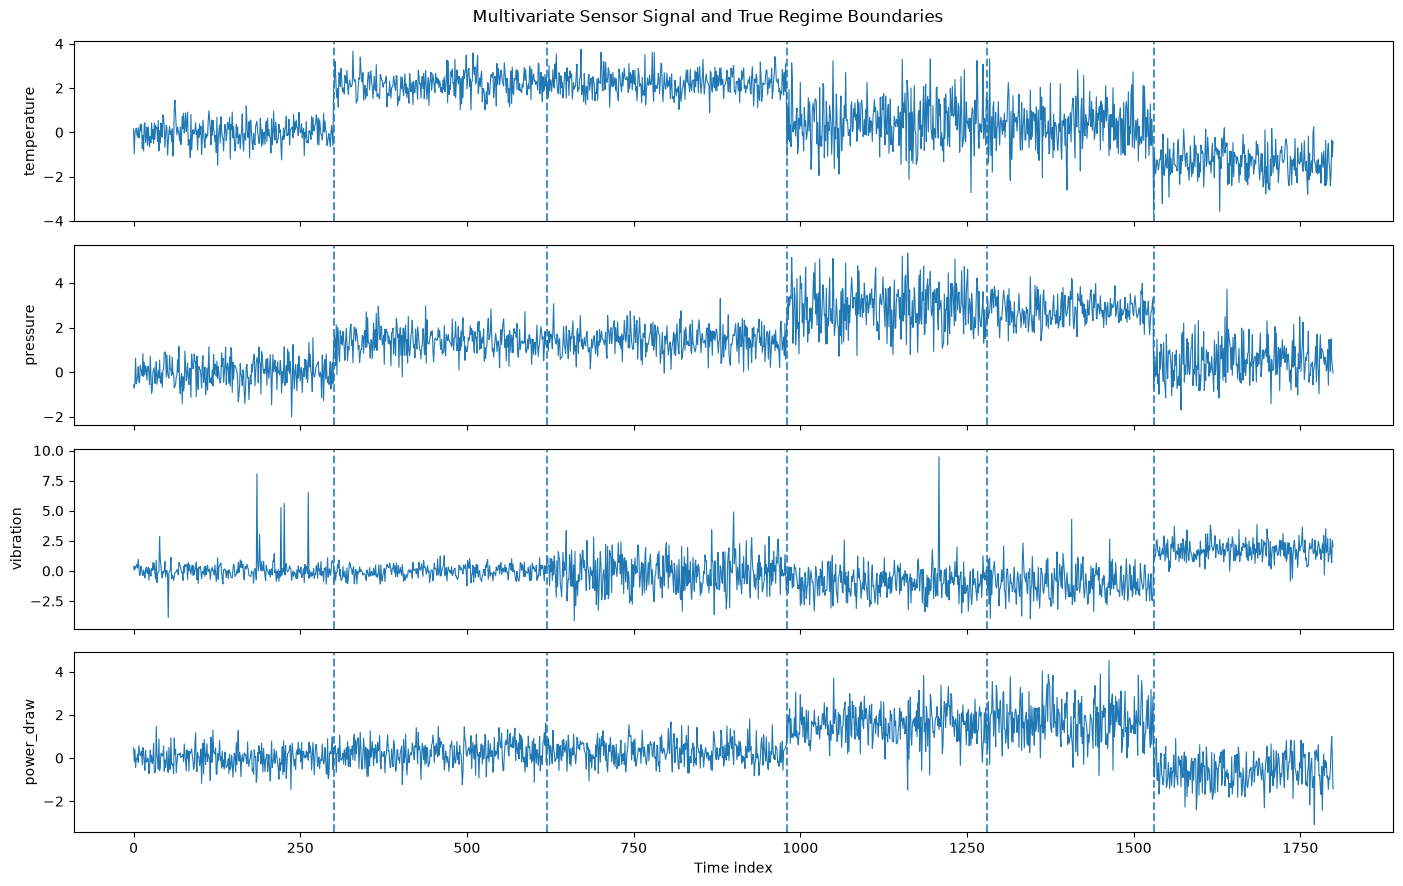

In [10]:
figure, axes = plt.subplots(
    len(SENSOR_COLUMNS),
    1,
    figsize=(14, 9),
    sharex=True
)

for axis, sensor_name in zip(
    axes,
    SENSOR_COLUMNS
):
    axis.plot(
        sensor_df["time_index"],
        sensor_df[sensor_name],
        linewidth=0.8
    )

    for change_point in (
        TRUE_CHANGE_POINTS
    ):
        axis.axvline(
            change_point,
            linestyle="--",
            alpha=0.8
        )

    axis.set_ylabel(sensor_name)

axes[-1].set_xlabel("Time index")

plt.suptitle(
    "Multivariate Sensor Signal and True Regime Boundaries"
)

plt.tight_layout()
plt.show()

## Sensor visualisation 

Several regime changes were clearly visible in the individual sensor plots.

At index 300:

- temperature increased from approximately 0 to 2.2
- pressure increased from approximately 0 to 1.4

At index 620, the vibration mean changed very little, but its variation increased substantially. This boundary was easier to observe from the spread of the vibration values than from their average.

At index 980, several simultaneous changes occurred:

- temperature decreased
- pressure increased
- vibration shifted downward
- power draw increased

At index 1,530, all four sensors showed a strong operating shift.

The boundary at index 1,280 was much harder to recognise from separate line plots. The individual means remained similar, while the relationship between the sensors changed.

The vibration channel also contained several large isolated spikes. These observations were visually extreme, but they did not represent persistent regime changes.

In [11]:
true_regime_summary = (
    sensor_df
    .groupby("true_regime")[
        SENSOR_COLUMNS
    ]
    .agg(["mean", "std"])
)

true_regime_summary

temperature            pressure           vibration            \
                   mean       std      mean       std      mean       std   
true_regime                                                                 
0             -0.021542  0.479461 -0.013650  0.561662  0.087216  0.928619   
1              2.193950  0.493509  1.404754  0.537351 -0.040390  0.469489   
2              2.232584  0.484564  1.423242  0.546792 -0.124885  1.390595   
3              0.473206  1.028376  2.905269  0.972781 -0.898019  1.222933   
4              0.331822  0.950248  2.784869  0.562801 -0.954952  1.198442   
5             -1.326447  0.676878  0.496349  0.818479  1.719641  0.761592   

            power_draw            
                  mean       std  
true_regime                       
0            -0.005480  0.474394  
1             0.254556  0.519695  
2             0.287626  0.507034  
3             1.549931  0.745146  
4             1.705371  0.957195  
5            -0.608423  0.710638

In [12]:
true_regime_correlations = {}

for regime_id, regime_df in (
    sensor_df.groupby("true_regime")
):
    true_regime_correlations[
        regime_id
    ] = regime_df[
        SENSOR_COLUMNS
    ].corr()

print("Regime 3 correlation matrix:")

display(
    true_regime_correlations[3]
)

print("Regime 4 correlation matrix:")

display(
    true_regime_correlations[4]
)

Regime 3 correlation matrix:


,temperature,pressure,vibration,power_draw
temperature,1.000000,0.633257,-0.038621,-0.014426
pressure,0.633257,1.000000,-0.009408,-0.019022
vibration,-0.038621,-0.009408,1.000000,-0.015719
power_draw,-0.014426,-0.019022,-0.015719,1.000000


Regime 4 correlation matrix:


,temperature,pressure,vibration,power_draw
temperature,1.000000,0.003606,0.028305,-0.575917
pressure,0.003606,1.000000,-0.013460,0.082463
vibration,0.028305,-0.013460,1.000000,-0.002747
power_draw,-0.575917,0.082463,-0.002747,1.000000


## Regime statistics 

The regime summaries confirmed several different types of process change.

### Mean changes

At the first boundary, the average values changed from approximately:

- Temperature: -0.02 to 2.19
- Pressure: -0.01 to 1.40

At index 980, the system moved to approximately:

- Temperature: 0.47
- Pressure: 2.91
- Vibration: -0.90
- Power draw: 1.55

The final regime had another large shift:

- Temperature: -1.33
- Pressure: 0.50
- Vibration: 1.72
- Power draw: -0.61

### Variance change

Between Regimes 1 and 2, most sensor means remained almost unchanged.

However, vibration standard deviation increased from:

`0.4695 to 1.3906`

This shows that a regime change can affect variability without substantially changing the average value.

### Correlation changes

In Regime 3, temperature and pressure had correlation:

`0.6333`

In Regime 4, this relationship almost disappeared:

`0.0036`

At the same time, temperature and power draw developed a strong negative correlation:

`-0.5759`

This boundary was therefore mainly defined by a change in cross-sensor dependence rather than individual sensor means.

In [13]:
scaler = StandardScaler()

scaled_signal = scaler.fit_transform(
    sensor_df[SENSOR_COLUMNS]
)

scaled_signal_df = pd.DataFrame(
    scaled_signal,
    columns=SENSOR_COLUMNS
)

scaled_signal_df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,1800.0,-5.684342e-16,1.000278,-3.050307,-0.742748,-0.030081,0.911549,2.064762
pressure,1800.0,6.000139e-16,1.000278,-2.791382,-0.717893,-0.043722,0.662823,3.092534
vibration,1800.0,1.973730e-17,1.000278,-3.034819,-0.578504,-0.014399,0.528186,7.077038
power_draw,1800.0,-3.157968e-17,1.000278,-3.468537,-0.647849,-0.155026,0.556562,3.890146


## Scaling 

All four sensor channels were standardised to approximately:

- mean 0
- standard deviation 1

This prevented a sensor with a larger numerical scale from dominating the multivariate RBF cost.

After scaling, changes in temperature, pressure, vibration, and power draw could contribute more comparably to the segmentation.

The scaling parameters were fitted using the complete simulated signal. This is acceptable for the offline experiment, although an online deployment would need to avoid using future observations when scaling incoming data.

In [15]:
def remove_final_endpoint(
    breakpoints,
    final_endpoint
):
    return [
        int(breakpoint)
        for breakpoint in breakpoints
        if int(breakpoint)
        != int(final_endpoint)
    ]

In [16]:
def match_change_points(
    true_change_points,
    predicted_change_points,
    tolerance=15
):
    unmatched_predictions = set(
        predicted_change_points
    )

    matched_pairs = []

    for true_change in (
        true_change_points
    ):
        valid_candidates = [
            prediction
            for prediction
            in unmatched_predictions
            if abs(
                prediction - true_change
            ) <= tolerance
        ]

        if not valid_candidates:
            continue

        closest_prediction = min(
            valid_candidates,
            key=lambda prediction:
                abs(
                    prediction
                    - true_change
                )
        )

        matched_pairs.append(
            (
                true_change,
                closest_prediction
            )
        )

        unmatched_predictions.remove(
            closest_prediction
        )

    return (
        matched_pairs,
        sorted(unmatched_predictions)
    )

In [17]:
def breakpoints_to_segment_labels(
    number_of_observations,
    breakpoints
):
    labels = np.zeros(
        number_of_observations,
        dtype=int
    )

    segment_start = 0

    for segment_id, segment_end in enumerate(
        breakpoints
    ):
        labels[
            segment_start:segment_end
        ] = segment_id

        segment_start = segment_end

    return labels

In [18]:
def calculate_hausdorff_distance(
    true_change_points,
    predicted_change_points
):
    if (
        len(true_change_points) == 0
        or len(predicted_change_points) == 0
    ):
        return np.inf

    true_to_predicted = max(
        min(
            abs(
                true_change
                - predicted_change
            )
            for predicted_change
            in predicted_change_points
        )
        for true_change
        in true_change_points
    )

    predicted_to_true = max(
        min(
            abs(
                predicted_change
                - true_change
            )
            for true_change
            in true_change_points
        )
        for predicted_change
        in predicted_change_points
    )

    return max(
        true_to_predicted,
        predicted_to_true
    )

In [19]:
def evaluate_change_points(
    true_change_points,
    predicted_breakpoints,
    number_of_observations,
    tolerance=15
):
    predicted_change_points = (
        remove_final_endpoint(
            predicted_breakpoints,
            number_of_observations
        )
    )

    matched_pairs, false_positives = (
        match_change_points(
            true_change_points,
            predicted_change_points,
            tolerance=tolerance
        )
    )

    true_positives = len(
        matched_pairs
    )

    false_negatives = (
        len(true_change_points)
        - true_positives
    )

    precision = (
        true_positives
        / len(predicted_change_points)
        if predicted_change_points
        else 0.0
    )

    recall = (
        true_positives
        / len(true_change_points)
        if true_change_points
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    boundary_errors = [
        abs(
            true_change
            - predicted_change
        )
        for (
            true_change,
            predicted_change
        )
        in matched_pairs
    ]

    true_segment_labels = (
        breakpoints_to_segment_labels(
            number_of_observations,
            (
                list(true_change_points)
                + [number_of_observations]
            )
        )
    )

    predicted_segment_labels = (
        breakpoints_to_segment_labels(
            number_of_observations,
            (
                predicted_change_points
                + [number_of_observations]
            )
        )
    )

    return {
        "predicted_change_points":
            predicted_change_points,

        "predicted_count":
            len(predicted_change_points),

        "true_positives":
            true_positives,

        "false_positives":
            len(false_positives),

        "false_negatives":
            false_negatives,

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "mean_boundary_error":
            (
                float(
                    np.mean(
                        boundary_errors
                    )
                )
                if boundary_errors
                else np.nan
            ),

        "hausdorff_distance":
            calculate_hausdorff_distance(
                true_change_points,
                predicted_change_points
            ),

        "adjusted_rand_index":
            adjusted_rand_score(
                true_segment_labels,
                predicted_segment_labels
            ),

        "matched_pairs":
            matched_pairs
    }

In [20]:
number_of_true_changes = len(
    TRUE_CHANGE_POINTS
)

equal_width_change_points = [
    int(
        round(
            NUMBER_OF_OBSERVATIONS
            * division
            / (
                number_of_true_changes
                + 1
            )
        )
    )
    for division in range(
        1,
        number_of_true_changes + 1
    )
]

equal_width_breakpoints = (
    equal_width_change_points
    + [NUMBER_OF_OBSERVATIONS]
)

print(
    "Equal-width predictions:",
    equal_width_change_points
)

Equal-width predictions: [300, 600, 900, 1200, 1500]


In [21]:
baseline_evaluation = (
    evaluate_change_points(
        true_change_points=
            TRUE_CHANGE_POINTS,
        predicted_breakpoints=
            equal_width_breakpoints,
        number_of_observations=
            NUMBER_OF_OBSERVATIONS,
        tolerance=
            MATCHING_TOLERANCE
    )
)

pd.DataFrame([baseline_evaluation]).drop(
    columns=[
        "predicted_change_points",
        "matched_pairs"
    ]
)

,predicted_count,true_positives,false_positives,false_negatives,precision,recall,f1,mean_boundary_error,hausdorff_distance,adjusted_rand_index
0,5,1,4,4,0.2,0.2,0.2,0.0,80,0.775054


## Equal-width baseline 

The equal-width baseline predicted:

`300, 600, 900, 1200, 1500`

It was given the correct number of change points but did not inspect any sensor values.

Its performance was:

- True positives: 1
- False positives: 4
- False negatives: 4
- Precision: 0.2000
- Recall: 0.2000
- F1-score: 0.2000
- Mean matched-boundary error: 0.0
- Hausdorff distance: 80
- Adjusted Rand Index: 0.7751

Only the boundary at 300 fell within the strict ±15 matching tolerance.

The reported mean boundary error of zero is therefore misleading when viewed alone. It describes only the one successfully matched boundary and does not account for the other four missed changes.

The relatively high Adjusted Rand Index shows that the equally spaced segments still overlapped broadly with the true regimes. This illustrates that boundary F1 and full-segmentation agreement measure different properties.

In [22]:
UNIVARIATE_PENALTY = 10.0

univariate_rows = []
univariate_predictions = {}

In [23]:
for sensor_name in SENSOR_COLUMNS:
    sensor_array = (
        scaled_signal_df[
            [sensor_name]
        ].to_numpy()
    )

    start_time = time.perf_counter()

    detector = rpt.Pelt(
        model="rbf",
        min_size=
            MINIMUM_SEGMENT_SIZE,
        jump=JUMP_SIZE
    ).fit(sensor_array)

    predicted_breakpoints = (
        detector.predict(
            pen=UNIVARIATE_PENALTY
        )
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    evaluation = (
        evaluate_change_points(
            true_change_points=
                TRUE_CHANGE_POINTS,
            predicted_breakpoints=
                predicted_breakpoints,
            number_of_observations=
                NUMBER_OF_OBSERVATIONS,
            tolerance=
                MATCHING_TOLERANCE
        )
    )

    univariate_predictions[
        sensor_name
    ] = predicted_breakpoints

    univariate_rows.append({
        "sensor": sensor_name,
        "runtime_seconds":
            elapsed_time,
        **{
            key: value
            for key, value
            in evaluation.items()
            if key not in [
                "predicted_change_points",
                "matched_pairs"
            ]
        }
    })

univariate_results_df = (
    pd.DataFrame(
        univariate_rows
    )
    .sort_values(
        "f1",
        ascending=False
    )
)

univariate_results_df

,sensor,runtime_seconds,predicted_count,true_positives,false_positives,false_negatives,precision,recall,f1,mean_boundary_error,hausdorff_distance,adjusted_rand_index
0,temperature,4.329669,3,3,0,2,1.0,0.6,0.75,0.000000,320,0.671944
1,pressure,4.940454,3,3,0,2,1.0,0.6,0.75,0.000000,320,0.671944
2,vibration,11.438855,3,3,0,2,1.0,0.6,0.75,0.666667,320,0.695373
3,power_draw,13.565889,3,3,0,2,1.0,0.6,0.75,2.000000,326,0.662758


## Individual-sensor detection 

Every individual sensor achieved the same boundary-level result:

- Detected changes: 3
- True positives: 3
- False positives: 0
- False negatives: 2
- Precision: 1.0000
- Recall: 0.6000
- F1-score: 0.7500

Their segmentation agreement differed:

| Sensor | Mean boundary error | Hausdorff distance | Adjusted Rand Index |
|---|---:|---:|---:|
| Temperature | 0.0000 | 320 | 0.6719 |
| Pressure | 0.0000 | 320 | 0.6719 |
| Vibration | 0.6667 | 320 | 0.6954 |
| Power draw | 2.0000 | 326 | 0.6628 |

There was no unique strongest sensor by F1 because all four achieved 0.7500.

Vibration produced the highest Adjusted Rand Index, making it the strongest individual channel when complete segmentation agreement was considered.

Power draw had the lowest ARI and largest boundary error.

No individual sensor detected all five system changes. This occurred because different boundaries affected different measurements. In particular, a change defined mainly by a relationship between sensors cannot be captured reliably from one channel alone.

The isolated vibration spikes did not create additional detected boundaries.

In [24]:
penalty_values = np.arange(
    4.0,
    30.1,
    2.0
)

penalty_rows = []
penalty_predictions = {}

In [29]:
for penalty in penalty_values:
    start_time = time.perf_counter()

    detector = rpt.Pelt(
        model="rbf",
        min_size=
            MINIMUM_SEGMENT_SIZE,
        jump=JUMP_SIZE
    ).fit(scaled_signal)

    predicted_breakpoints = (
        detector.predict(
            pen=float(penalty)
        )
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    evaluation = (
        evaluate_change_points(
            true_change_points=
                TRUE_CHANGE_POINTS,
            predicted_breakpoints=
                predicted_breakpoints,
            number_of_observations=
                NUMBER_OF_OBSERVATIONS,
            tolerance=
                MATCHING_TOLERANCE
        )
    )

    penalty_predictions[
        float(penalty)
    ] = predicted_breakpoints

    penalty_rows.append({
        "penalty": float(penalty),
        "runtime_seconds":
            elapsed_time,
        **{
            key: value
            for key, value
            in evaluation.items()
            if key not in [
                "predicted_change_points",
                "matched_pairs"
            ]
        }
    })

penalty_results_df = pd.DataFrame(
    penalty_rows
)

penalty_results_df

,penalty,runtime_seconds,predicted_count,true_positives,false_positives,false_negatives,precision,recall,f1,mean_boundary_error,hausdorff_distance,adjusted_rand_index
0,4.0,6.223576,4,4,0,1,1.0,0.8,0.888889,3.5,250,0.832410
1,6.0,5.324634,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
2,8.0,5.198354,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
3,10.0,5.143773,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
4,12.0,5.016922,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
5,14.0,5.097819,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
6,16.0,5.694837,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
7,4.0,2.605696,4,4,0,1,1.0,0.8,0.888889,3.5,250,0.832410
8,6.0,3.141134,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944
9,8.0,3.273499,3,3,0,2,1.0,0.6,0.750000,0.0,320,0.671944


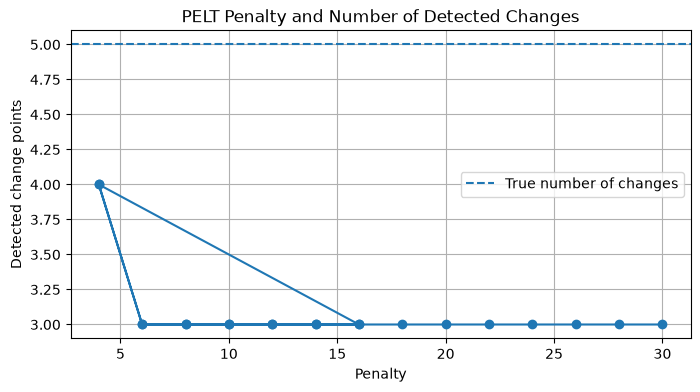

In [30]:
plt.figure(figsize=(8, 4))

plt.plot(
    penalty_results_df["penalty"],
    penalty_results_df[
        "predicted_count"
    ],
    marker="o"
)

plt.axhline(
    len(TRUE_CHANGE_POINTS),
    linestyle="--",
    label="True number of changes"
)

plt.title("PELT Penalty and Number of Detected Changes")
plt.xlabel("Penalty")
plt.ylabel("Detected change points")
plt.legend()
plt.grid(True)
plt.show()

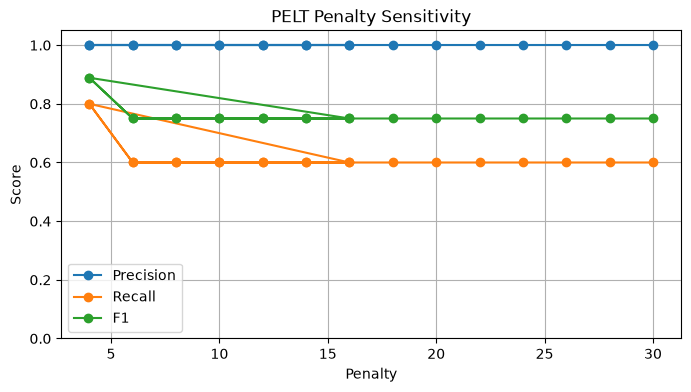

In [31]:
plt.figure(figsize=(8, 4))

plt.plot(
    penalty_results_df["penalty"],
    penalty_results_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    penalty_results_df["penalty"],
    penalty_results_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    penalty_results_df["penalty"],
    penalty_results_df["f1"],
    marker="o",
    label="F1"
)

plt.title("PELT Penalty Sensitivity")
plt.xlabel("Penalty")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

## Penalty-sensitivity 

The tested PELT penalties produced two distinct segmentation patterns.

| Penalty | Detected changes | Precision | Recall | F1 |
|---:|---:|---:|---:|---:|
| 4 | 4 | 1.0000 | 0.8000 | 0.8889 |
| 6–30 | 3 | 1.0000 | 0.6000 | 0.7500 |

Penalty 4 detected:

`300, 634, 980, 1530`

Penalties from 6 through 30 retained only three changes. These higher penalties under-segmented the signal by treating additional regimes as parts of larger segments.

None of the tested penalties produced false-positive changes. The main trade-off was therefore between:

- retaining weaker genuine changes
- merging them into neighbouring regimes

Even the lowest tested penalty did not recover the true boundary at 1,280. That transition was driven mainly by a correlation change and was weaker under the selected RBF segmentation objective than the large mean and variance changes.

In real data, the true boundaries would not be available for selecting penalty 4. Penalty choice would instead require stability analysis, domain knowledge, or a separately labelled validation period.

In [32]:
penalty_selection_df = (
    penalty_results_df
    .copy()
)

penalty_selection_df[
    "finite_boundary_error"
] = (
    penalty_selection_df[
        "mean_boundary_error"
    ].fillna(np.inf)
)

best_penalty_row = (
    penalty_selection_df
    .sort_values(
        [
            "f1",
            "adjusted_rand_index",
            "finite_boundary_error",
            "predicted_count"
        ],
        ascending=[
            False,
            False,
            True,
            True
        ]
    )
    .iloc[0]
)

SELECTED_PELT_PENALTY = float(
    best_penalty_row["penalty"]
)

pelt_breakpoints = (
    penalty_predictions[
        SELECTED_PELT_PENALTY
    ]
)

pelt_evaluation = (
    evaluate_change_points(
        true_change_points=
            TRUE_CHANGE_POINTS,
        predicted_breakpoints=
            pelt_breakpoints,
        number_of_observations=
            NUMBER_OF_OBSERVATIONS,
        tolerance=
            MATCHING_TOLERANCE
    )
)

print(
    "Selected PELT penalty:",
    SELECTED_PELT_PENALTY
)

print(
    "Detected change points:",
    pelt_evaluation[
        "predicted_change_points"
    ]
)

print(
    "Matched pairs:",
    pelt_evaluation[
        "matched_pairs"
    ]
)

Selected PELT penalty: 4.0
Detected change points: [300, 634, 980, 1530]
Matched pairs: [(300, 300), (620, 634), (980, 980), (1530, 1530)]


## Selected PELT result 

The selected PELT penalty was:

`4.0`

The detector predicted:

`300, 634, 980, 1530`

The matched true and predicted pairs were:

| True boundary | PELT boundary | Absolute error |
|---:|---:|---:|
| 300 | 300 | 0 |
| 620 | 634 | 14 |
| 980 | 980 | 0 |
| 1,530 | 1,530 | 0 |

The result was:

- Predicted changes: 4
- True positives: 4
- False positives: 0
- False negatives: 1
- Precision: 1.0000
- Recall: 0.8000
- F1-score: 0.8889
- Mean boundary error: 3.5
- Hausdorff distance: 250
- Adjusted Rand Index: 0.8324

Three boundaries were located exactly, while the vibration-variance change was detected 14 observations late.

The boundary at 1,280 was missed. Its nearest detected boundary was 250 observations away, explaining the relatively large Hausdorff distance despite the small mean error among successfully matched boundaries.

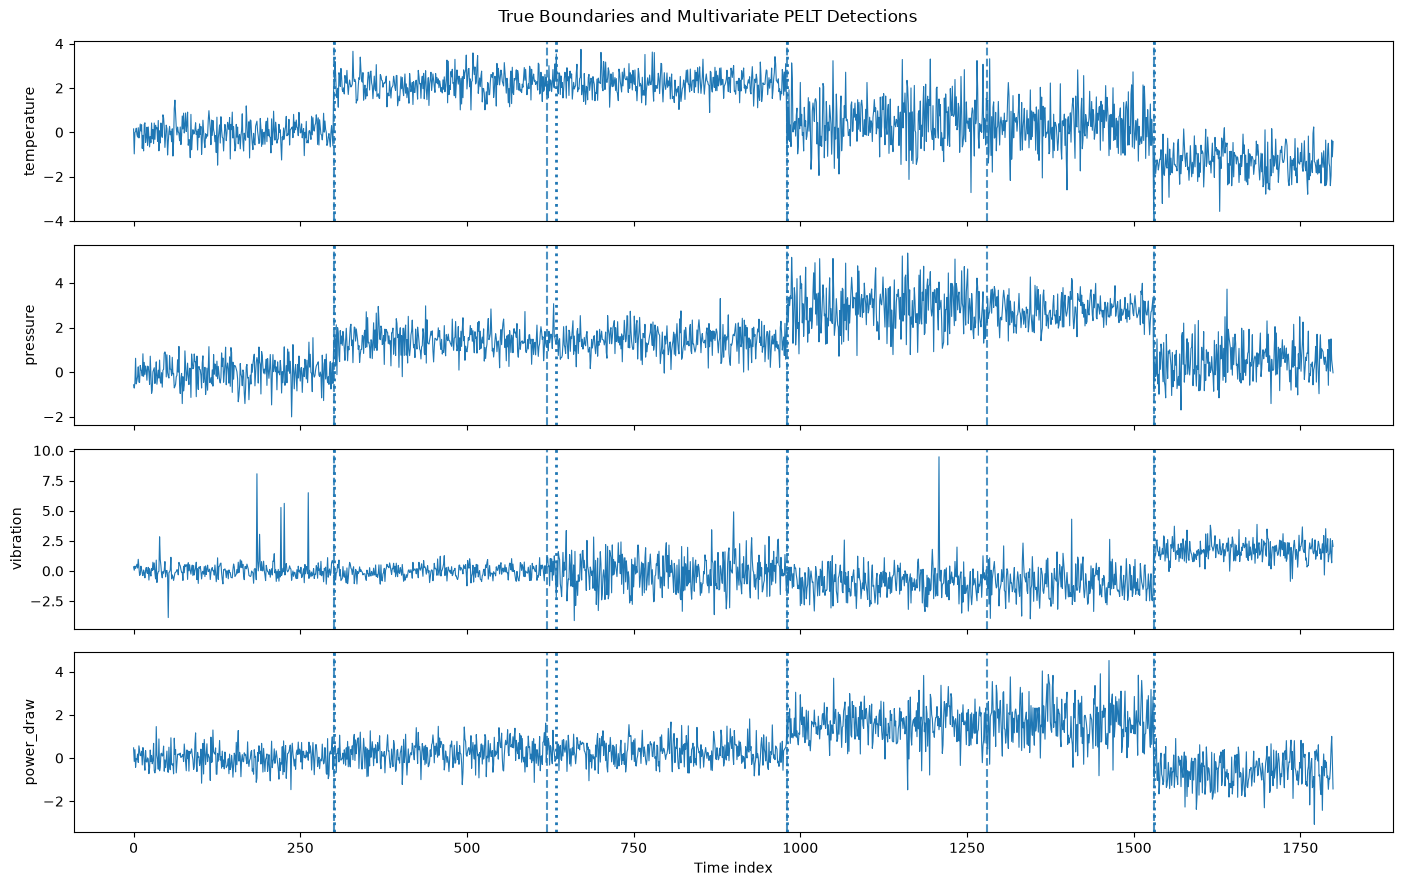

In [33]:
pelt_change_points = (
    pelt_evaluation[
        "predicted_change_points"
    ]
)

figure, axes = plt.subplots(
    len(SENSOR_COLUMNS),
    1,
    figsize=(14, 9),
    sharex=True
)

for axis, sensor_name in zip(
    axes,
    SENSOR_COLUMNS
):
    axis.plot(
        sensor_df["time_index"],
        sensor_df[sensor_name],
        linewidth=0.8
    )

    for change_point in (
        TRUE_CHANGE_POINTS
    ):
        axis.axvline(
            change_point,
            linestyle="--",
            alpha=0.8
        )

    for detected_change in (
        pelt_change_points
    ):
        axis.axvline(
            detected_change,
            linestyle=":",
            linewidth=2
        )

    axis.set_ylabel(sensor_name)

axes[-1].set_xlabel("Time index")

plt.suptitle(
    "True Boundaries and Multivariate PELT Detections"
)

plt.tight_layout()
plt.show()

## PELT visual result note

PELT aligned exactly with the true boundaries at:

- 300
- 980
- 1,530

It placed the second change at 634 rather than 620, which was still within the ±15 matching tolerance.

The detector did not create boundaries around the isolated vibration spikes. This suggests that the penalty and minimum segment size successfully distinguished temporary anomalies from persistent changes.

The true boundary at 1,280 was missed. The detector combined the true regimes from 980 to 1,530 into one longer detected segment.

This is consistent with the plotted signal: the change at 1,280 was difficult to see in individual sensor levels because it primarily altered correlation structure.

In [34]:
algorithm_rows = []
algorithm_predictions = {}

algorithm_builders = {
    "PELT": lambda: rpt.Pelt(
        model="rbf",
        min_size=
            MINIMUM_SEGMENT_SIZE,
        jump=JUMP_SIZE
    ),

    "Binary Segmentation":
        lambda: rpt.Binseg(
            model="rbf",
            min_size=
                MINIMUM_SEGMENT_SIZE,
            jump=JUMP_SIZE
        ),

    "Window":
        lambda: rpt.Window(
            width=80,
            model="rbf",
            min_size=
                MINIMUM_SEGMENT_SIZE,
            jump=JUMP_SIZE
        )
}

In [35]:
for algorithm_name, builder in (
    algorithm_builders.items()
):
    start_time = time.perf_counter()

    detector = builder().fit(
        scaled_signal
    )

    if algorithm_name == "PELT":
        predicted_breakpoints = (
            detector.predict(
                pen=
                    SELECTED_PELT_PENALTY
            )
        )
    else:
        predicted_breakpoints = (
            detector.predict(
                n_bkps=
                    len(
                        TRUE_CHANGE_POINTS
                    )
            )
        )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    evaluation = (
        evaluate_change_points(
            true_change_points=
                TRUE_CHANGE_POINTS,
            predicted_breakpoints=
                predicted_breakpoints,
            number_of_observations=
                NUMBER_OF_OBSERVATIONS,
            tolerance=
                MATCHING_TOLERANCE
        )
    )

    algorithm_predictions[
        algorithm_name
    ] = predicted_breakpoints

    algorithm_rows.append({
        "algorithm":
            algorithm_name,
        "runtime_seconds":
            elapsed_time,
        **{
            key: value
            for key, value
            in evaluation.items()
            if key not in [
                "predicted_change_points",
                "matched_pairs"
            ]
        }
    })

algorithm_comparison_df = (
    pd.DataFrame(
        algorithm_rows
    )
    .sort_values(
        "f1",
        ascending=False
    )
)

algorithm_comparison_df

,algorithm,runtime_seconds,predicted_count,true_positives,false_positives,false_negatives,precision,recall,f1,mean_boundary_error,hausdorff_distance,adjusted_rand_index
1,Binary Segmentation,1.874358,5,5,0,0,1.0,1.0,1.000000,5.2,14,0.965175
0,PELT,4.518632,4,4,0,1,1.0,0.8,0.888889,3.5,250,0.832410
2,Window,0.135554,5,3,2,2,0.6,0.6,0.600000,0.0,320,0.662054


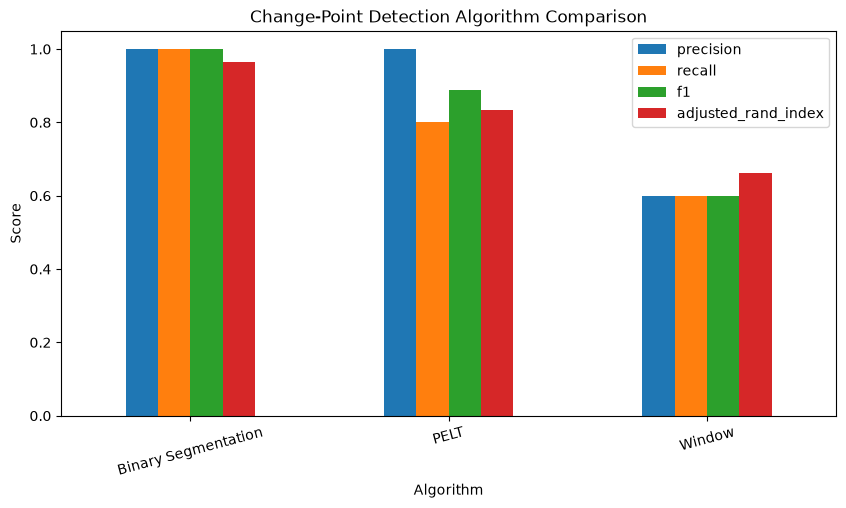

In [36]:
algorithm_comparison_df.set_index(
    "algorithm"
)[
    [
        "precision",
        "recall",
        "f1",
        "adjusted_rand_index"
    ]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Change-Point Detection Algorithm Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.show()

## Algorithm comparison 

Algorithm performance was:

| Algorithm | Detected changes | Precision | Recall | F1 | Mean boundary error | Hausdorff distance | ARI | Runtime |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Binary Segmentation | 5 | 1.0000 | 1.0000 | 1.0000 | 5.2 | 14 | 0.9652 | 1.874 s |
| PELT | 4 | 1.0000 | 0.8000 | 0.8889 | 3.5 | 250 | 0.8324 | 4.519 s |
| Window | 5 | 0.6000 | 0.6000 | 0.6000 | 0.0 | 320 | 0.6621 | 0.136 s |

Binary Segmentation achieved the strongest result. It detected all five changes within the matching tolerance and produced the highest Adjusted Rand Index.

Window detection was the fastest method, but it matched only three true boundaries and produced two false positives.

Its mean boundary error of zero applies only to its three successful matches. It should not be interpreted as superior boundary performance because two genuine boundaries were missed and two incorrect changes were introduced.

Binary Segmentation and Window detection were explicitly given the correct number of changes. PELT had the more difficult task of determining the number of changes from its penalty.

In [37]:
def characterise_change(
    signal_array,
    change_point,
    window_size=40
):
    left_start = max(
        0,
        change_point - window_size
    )

    right_end = min(
        len(signal_array),
        change_point + window_size
    )

    before = signal_array[
        left_start:change_point
    ]

    after = signal_array[
        change_point:right_end
    ]

    before_mean = before.mean(axis=0)
    after_mean = after.mean(axis=0)

    before_variance = before.var(
        axis=0
    )

    after_variance = after.var(
        axis=0
    )

    mean_shift = float(
        np.linalg.norm(
            after_mean - before_mean
        )
    )

    variance_shift = float(
        np.linalg.norm(
            np.log(
                (
                    after_variance
                    + 1e-6
                )
                / (
                    before_variance
                    + 1e-6
                )
            )
        )
    )

    before_correlation = np.corrcoef(
        before,
        rowvar=False
    )

    after_correlation = np.corrcoef(
        after,
        rowvar=False
    )

    correlation_shift = float(
        np.linalg.norm(
            after_correlation
            - before_correlation,
            ord="fro"
        )
    )

    change_scores = {
        "Mean shift": mean_shift,
        "Variance shift":
            variance_shift,
        "Correlation shift":
            correlation_shift
    }

    dominant_change = max(
        change_scores,
        key=change_scores.get
    )

    return {
        "change_point":
            change_point,
        "mean_shift_score":
            mean_shift,
        "variance_shift_score":
            variance_shift,
        "correlation_shift_score":
            correlation_shift,
        "dominant_change":
            dominant_change
    }

In [38]:
change_characterisation_df = (
    pd.DataFrame([
        characterise_change(
            scaled_signal,
            change_point,
            window_size=40
        )
        for change_point
        in pelt_change_points
    ])
)

change_characterisation_df

,change_point,mean_shift_score,variance_shift_score,correlation_shift_score,dominant_change
0,300,1.845664,1.546461,1.062690,Mean shift
1,634,0.271407,1.814236,0.279285,Variance shift
2,980,2.209483,2.044712,1.201627,Mean shift
3,1530,3.842246,1.410914,1.246405,Mean shift


## Change characterisation 

The four PELT changes were characterised as:

| Change point | Mean-shift score | Variance-shift score | Correlation-shift score | Dominant type |
|---:|---:|---:|---:|---|
| 300 | 1.8457 | 1.5465 | 1.0627 | Mean shift |
| 634 | 0.2714 | 1.8142 | 0.2793 | Variance shift |
| 980 | 2.2095 | 2.0447 | 1.2016 | Mean shift |
| 1,530 | 3.8422 | 1.4109 | 1.2464 | Mean shift |

The detection at 634 was correctly characterised as a variance change. Its mean-shift score was small, while its variance score was much larger.

The changes at 300, 980, and 1,530 were dominated by shifts in sensor means.

The largest overall mean-shift score occurred at 1,530, matching the visibly large system-wide transition.

The scores are descriptive summaries based on local windows. They do not establish the physical cause of a process change.

In [39]:
def summarise_detected_segments(
    signal_frame,
    detected_breakpoints,
    sensor_columns
):
    summary_rows = []

    segment_start = 0

    for segment_id, segment_end in enumerate(
        detected_breakpoints
    ):
        segment_df = signal_frame.iloc[
            segment_start:segment_end
        ]

        summary_row = {
            "detected_segment":
                segment_id,
            "start":
                segment_start,
            "end":
                segment_end,
            "length":
                segment_end
                - segment_start
        }

        for sensor_name in sensor_columns:
            summary_row[
                f"{sensor_name}_mean"
            ] = segment_df[
                sensor_name
            ].mean()

            summary_row[
                f"{sensor_name}_std"
            ] = segment_df[
                sensor_name
            ].std()

        summary_rows.append(
            summary_row
        )

        segment_start = segment_end

    return pd.DataFrame(
        summary_rows
    )

In [40]:
detected_segment_summary_df = (
    summarise_detected_segments(
        signal_frame=sensor_df,
        detected_breakpoints=
            pelt_breakpoints,
        sensor_columns=
            SENSOR_COLUMNS
    )
)

detected_segment_summary_df

,detected_segment,start,end,length,temperature_mean,temperature_std,pressure_mean,pressure_std,vibration_mean,vibration_std,power_draw_mean,power_draw_std
0,0,0,300,300,-0.021542,0.479461,-0.013650,0.561662,0.087216,0.928619,-0.005480,0.474394
1,1,300,634,334,2.196217,0.491973,1.411798,0.536915,-0.025976,0.493645,0.258695,0.517916
2,2,634,980,346,2.231959,0.485811,1.417190,0.547725,-0.142218,1.406298,0.284969,0.508462
3,3,980,1530,550,0.408940,0.995230,2.850542,0.814029,-0.923898,1.211095,1.620585,0.850856
4,4,1530,1800,270,-1.326447,0.676878,0.496349,0.818479,1.719641,0.761592,-0.608423,0.710638


## Detected regime 

PELT produced five detected operating segments.

### Segment 0: indices 0–300

This represented the initial operating state:

- Temperature mean: -0.02
- Pressure mean: -0.01
- Vibration mean: 0.09
- Power mean: -0.01

All channels were centred near zero.

### Segment 1: indices 300–634

Temperature and pressure shifted upward:

- Temperature mean: 2.20
- Pressure mean: 1.41

Vibration remained relatively stable, with standard deviation 0.49.

### Segment 2: indices 634–980

Temperature and pressure remained at similar levels, but vibration standard deviation increased to:

`1.41`

This segment captured the high-vibration-variance regime.

### Segment 3: indices 980–1,530

The detector combined two true regimes into one segment:

- Temperature mean: 0.41
- Pressure mean: 2.85
- Vibration mean: -0.92
- Power mean: 1.62

The true dependence change at 1,280 was not represented as a separate PELT segment.

### Segment 4: indices 1,530–1,800

The final operating state had:

- Temperature mean: -1.33
- Pressure mean: 0.50
- Vibration mean: 1.72
- Power mean: -0.61

The detected segments therefore captured the major level and variance regimes but merged the two regimes distinguished primarily by correlation structure.

In [41]:
sensor_subsets = {
    "Temperature only":
        ["temperature"],

    "Vibration only":
        ["vibration"],

    "Mean-oriented pair":
        [
            "temperature",
            "pressure"
        ],

    "All sensors":
        SENSOR_COLUMNS
}

In [42]:
subset_rows = []

for subset_name, subset_columns in (
    sensor_subsets.items()
):
    subset_signal = (
        scaled_signal_df[
            subset_columns
        ].to_numpy()
    )

    detector = rpt.Pelt(
        model="rbf",
        min_size=
            MINIMUM_SEGMENT_SIZE,
        jump=JUMP_SIZE
    ).fit(subset_signal)

    subset_breakpoints = (
        detector.predict(
            pen=
                SELECTED_PELT_PENALTY
        )
    )

    evaluation = (
        evaluate_change_points(
            true_change_points=
                TRUE_CHANGE_POINTS,
            predicted_breakpoints=
                subset_breakpoints,
            number_of_observations=
                NUMBER_OF_OBSERVATIONS,
            tolerance=
                MATCHING_TOLERANCE
        )
    )

    subset_rows.append({
        "sensor_subset":
            subset_name,
        "number_of_sensors":
            len(subset_columns),
        **{
            key: value
            for key, value
            in evaluation.items()
            if key not in [
                "predicted_change_points",
                "matched_pairs"
            ]
        }
    })

sensor_subset_df = pd.DataFrame(
    subset_rows
)

sensor_subset_df

,sensor_subset,number_of_sensors,predicted_count,true_positives,false_positives,false_negatives,precision,recall,f1,mean_boundary_error,hausdorff_distance,adjusted_rand_index
0,Temperature only,1,3,3,0,2,1.0,0.6,0.750000,0.000000,320,0.671944
1,Vibration only,1,3,3,0,2,1.0,0.6,0.750000,0.666667,320,0.695373
2,Mean-oriented pair,2,4,4,0,1,1.0,0.8,0.888889,3.000000,320,0.770352
3,All sensors,4,4,4,0,1,1.0,0.8,0.888889,3.500000,250,0.832410


## Sensor ablation 

Sensor-subset performance was:

| Sensor subset | Sensors | Precision | Recall | F1 | Boundary error | Hausdorff | ARI |
|---|---:|---:|---:|---:|---:|---:|---:|
| Temperature only | 1 | 1.0000 | 0.6000 | 0.7500 | 0.0000 | 320 | 0.6719 |
| Vibration only | 1 | 1.0000 | 0.6000 | 0.7500 | 0.6667 | 320 | 0.6954 |
| Temperature and pressure | 2 | 1.0000 | 0.8000 | 0.8889 | 3.0000 | 320 | 0.7704 |
| All sensors | 4 | 1.0000 | 0.8000 | 0.8889 | 3.5000 | 250 | 0.8324 |

Combining temperature and pressure increased recall from 0.60 to 0.80.

Using all four sensors did not increase boundary F1 beyond the two-sensor pair, but it produced:

- the highest Adjusted Rand Index
- the smallest Hausdorff distance
- better agreement with the complete true segmentation

This shows that the additional sensors contributed useful regime information even when they did not increase the number of matched boundaries.

More variables were useful because the sensors contained complementary information. However, the all-sensor model still failed to isolate the correlation-only boundary at 1,280.

In [43]:
def generate_stationary_control_signal(
    number_of_observations,
    random_state=123
):
    rng = np.random.default_rng(
        random_state
    )

    signal = rng.normal(
        loc=0.0,
        scale=1.0,
        size=(
            number_of_observations,
            len(SENSOR_COLUMNS)
        )
    )

    spike_indices = rng.choice(
        np.arange(
            30,
            number_of_observations - 30
        ),
        size=18,
        replace=False
    )

    signal[
        spike_indices,
        2
    ] += rng.normal(
        loc=0.0,
        scale=5.0,
        size=len(spike_indices)
    )

    return signal, spike_indices

In [44]:
stationary_signal, stationary_spikes = (
    generate_stationary_control_signal(
        NUMBER_OF_OBSERVATIONS,
        random_state=
            RANDOM_STATE + 100
    )
)

stationary_scaled = (
    StandardScaler()
    .fit_transform(
        stationary_signal
    )
)

In [45]:
stationary_breakpoints = (
    rpt.Pelt(
        model="rbf",
        min_size=
            MINIMUM_SEGMENT_SIZE,
        jump=JUMP_SIZE
    )
    .fit(stationary_scaled)
    .predict(
        pen=
            SELECTED_PELT_PENALTY
    )
)

stationary_change_points = (
    remove_final_endpoint(
        stationary_breakpoints,
        NUMBER_OF_OBSERVATIONS
    )
)

print(
    "Stationary false change points:",
    stationary_change_points
)

print(
    "Number of false alarms:",
    len(stationary_change_points)
)

Stationary false change points: []
Number of false alarms: 0


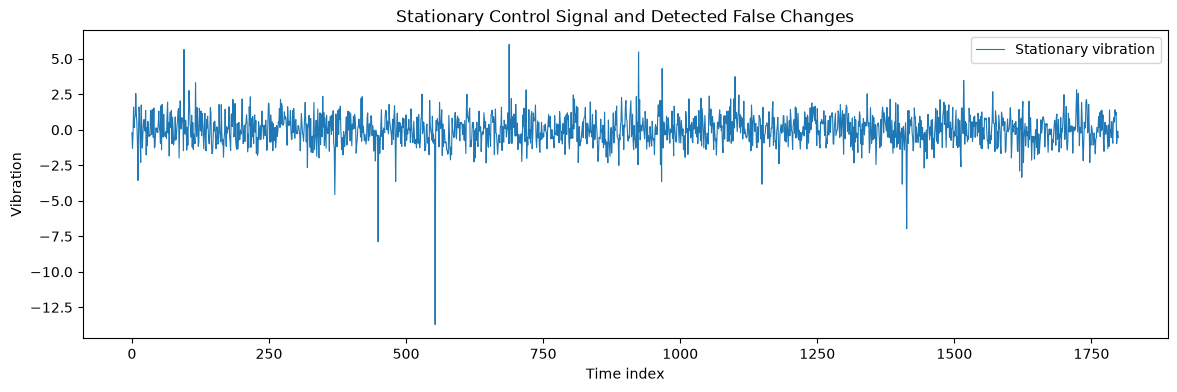

In [46]:
plt.figure(figsize=(14, 4))

plt.plot(
    stationary_signal[:, 2],
    linewidth=0.8,
    label="Stationary vibration"
)

for detected_change in (
    stationary_change_points
):
    plt.axvline(
        detected_change,
        linestyle="--"
    )

plt.title(
    "Stationary Control Signal and Detected False Changes"
)

plt.xlabel("Time index")
plt.ylabel("Vibration")
plt.legend()
plt.show()

## Stationary false alarm 

The stationary control signal contained:

- random multivariate noise
- 18 large vibration spikes
- no permanent regime changes

PELT detected:

`No change points`

The number of false alarms was:

`0`

This is a strong result because the detector did not convert isolated extreme observations into persistent operating-regime boundaries.

The combination of:

- RBF cost
- penalty 4
- minimum segment size 40

was sufficiently resistant to the temporary spikes in this control experiment.

This does not prove that the detector will never generate false alarms on real sensor data, but it shows that individual outliers alone were insufficient to trigger segmentation here.

In [47]:
def generate_gradual_drift_signal(
    number_of_observations=1_200,
    drift_start=400,
    drift_end=800,
    random_state=900
):
    rng = np.random.default_rng(
        random_state
    )

    signal = rng.normal(
        loc=0.0,
        scale=0.55,
        size=(
            number_of_observations,
            len(SENSOR_COLUMNS)
        )
    )

    drift_progress = np.zeros(
        number_of_observations
    )

    drift_progress[
        drift_start:drift_end
    ] = np.linspace(
        0,
        1,
        drift_end - drift_start,
        endpoint=False
    )

    drift_progress[
        drift_end:
    ] = 1.0

    signal[:, 0] += (
        2.5 * drift_progress
    )

    signal[:, 1] += (
        1.5 * drift_progress
    )

    signal[:, 3] -= (
        1.2 * drift_progress
    )

    return signal

In [48]:
DRIFT_START = 400
DRIFT_END = 800

gradual_signal = (
    generate_gradual_drift_signal(
        number_of_observations=1_200,
        drift_start=DRIFT_START,
        drift_end=DRIFT_END,
        random_state=
            RANDOM_STATE + 200
    )
)

gradual_scaled = (
    StandardScaler()
    .fit_transform(
        gradual_signal
    )
)

In [49]:
gradual_breakpoints = (
    rpt.Pelt(
        model="rbf",
        min_size=
            MINIMUM_SEGMENT_SIZE,
        jump=JUMP_SIZE
    )
    .fit(gradual_scaled)
    .predict(
        pen=
            SELECTED_PELT_PENALTY
    )
)

gradual_change_points = (
    remove_final_endpoint(
        gradual_breakpoints,
        len(gradual_signal)
    )
)

print(
    "Gradual-drift detections:",
    gradual_change_points
)

Gradual-drift detections: [480, 640, 760]


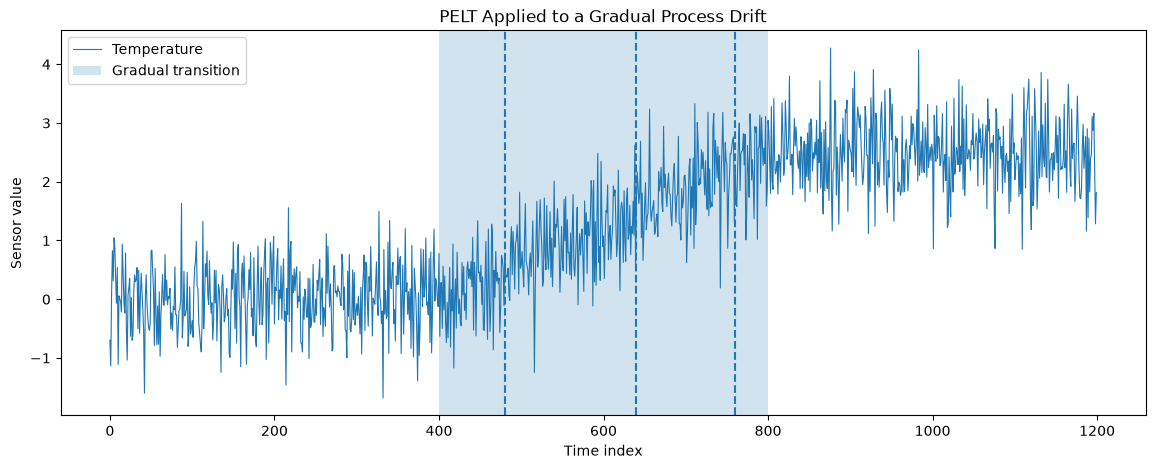

In [50]:
plt.figure(figsize=(14, 5))

plt.plot(
    gradual_signal[:, 0],
    linewidth=0.8,
    label="Temperature"
)

plt.axvspan(
    DRIFT_START,
    DRIFT_END,
    alpha=0.2,
    label="Gradual transition"
)

for detected_change in (
    gradual_change_points
):
    plt.axvline(
        detected_change,
        linestyle="--"
    )

plt.title(
    "PELT Applied to a Gradual Process Drift"
)

plt.xlabel("Time index")
plt.ylabel("Sensor value")
plt.legend()
plt.show()

## Gradual drift 

The gradual process transition occurred from index:

`400 to 800`

PELT detected boundaries at:

`480, 640, 760`

All three detections were located inside the gradual transition region.

Rather than representing the smooth drift with one change point, PELT approximated it using several stepwise regimes:

- an early transition around 480
- an intermediate level around 640
- a later transition around 760

No unique abrupt boundary actually existed in the generated data.

This demonstrates an important limitation of standard change-point detection: a continuous drift may be converted into several artificial discrete changes. In this setting, evaluating against one exact timestamp would not adequately represent detection quality.

In [51]:
best_algorithm_row = (
    algorithm_comparison_df
    .sort_values(
        [
            "f1",
            "adjusted_rand_index"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0]
)

best_sensor_row = (
    univariate_results_df
    .sort_values(
        [
            "f1",
            "adjusted_rand_index"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0]
)

In [52]:
final_summary_df = pd.DataFrame({
    "metric": [
        "Observations",
        "Sensors",
        "True regimes",
        "True change points",
        "Equal-width baseline F1",
        "Selected PELT penalty",
        "PELT detected changes",
        "PELT precision",
        "PELT recall",
        "PELT F1",
        "PELT mean boundary error",
        "PELT Adjusted Rand Index",
        "Best comparison algorithm",
        "Best individual sensor",
        "Stationary false alarms",
        "Gradual-drift detections"
    ],
    "value": [
        NUMBER_OF_OBSERVATIONS,
        len(SENSOR_COLUMNS),
        len(TRUE_CHANGE_POINTS) + 1,
        len(TRUE_CHANGE_POINTS),
        baseline_evaluation["f1"],
        SELECTED_PELT_PENALTY,
        pelt_evaluation[
            "predicted_count"
        ],
        pelt_evaluation[
            "precision"
        ],
        pelt_evaluation[
            "recall"
        ],
        pelt_evaluation["f1"],
        pelt_evaluation[
            "mean_boundary_error"
        ],
        pelt_evaluation[
            "adjusted_rand_index"
        ],
        best_algorithm_row[
            "algorithm"
        ],
        best_sensor_row["sensor"],
        len(
            stationary_change_points
        ),
        str(
            gradual_change_points
        )
    ]
})

final_summary_df

,metric,value
0,Observations,1800
1,Sensors,4
2,True regimes,6
3,True change points,5
4,Equal-width baseline F1,0.2
5,Selected PELT penalty,4.0
6,PELT detected changes,4
7,PELT precision,1.0
8,PELT recall,0.8
9,PELT F1,0.888889
